# Quantum Machine Learning Model for the Sine Function

We implement a variational QML model to learn the function $y = \sin(x)$ on the interval $[0, 2\pi]$.
We discretize this interval into finitely many points, use the corresponding sine values as labels, and train a quantum circuit so that its outputs reproduce the shape of the sine curve.

## Environment Preparation
We need to install PennyLane to our notebook first.

In [1]:
# %pip install pennylane # uncommment this to install

After the installation, we import PennyLane as `qml`. For this notebook, the `numpy` library is required. Fortunately, we do not need to install it separately, since PennyLane already provides it.

We also import the `AdamOptimizer` from PennyLane, as it is a robust gradient-based optimizer that adapts its learning rate during training and typically converges faster and more stably than standard gradient descent.

Finally, we import `matplotlib` to visualize both the true sine function and the predictions of our model.

In [2]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer

import matplotlib.pyplot as plt

## Data Generation

We discretize the interval $[0, 2\pi]$ into $N$ equally spaced points and compute the corresponding labels $y = \sin(x)$.

In [3]:
np.random.seed(42)
N = 100

X_all = np.linspace(0, 2 * np.pi, N, endpoint=False)
Y_all = np.sin(X_all)

We then randomly split these points into a training set and a validation set. The training set is used to update the model parameters, while the validation set is used to monitor how well the model generalizes to points that it has not seen during training.

In [4]:
n_train = int(0.8 * N) # 80% of data is used as training data set
idx = np.random.permutation(N)
train_idx, val_idx = idx[:n_train], idx[n_train:]

# for training data
X_train = X_all[train_idx] # first 80%
Y_train = Y_all[train_idx]

# for validation data
X_val = X_all[val_idx] # remaining 20%
Y_val = Y_all[val_idx]

print(f"Total points: {N}, Train: {n_train}, Validation: {N - n_train}")

Total points: 100, Train: 80, Validation: 20


## Preparing States (or) Input Encoding

We use a single qubit simulated with the `default.qubit` device. We encode each scalar input $x \in [0, 2\pi]$ into the quantum state by applying a rotation gate $R_y(x)$ on this qubit. In this way, different values of $x$ correspond to different quantum states on the Bloch sphere.

Example:

- $x \rightarrow | \psi(x) \rangle$
    - $| \psi(x) \rangle = R_y(x)\,|0\rangle$, assuming we start from the ground state $|0\rangle$.

In [5]:
n_qubits = 1
dev = qml.device("default.qubit", wires=n_qubits)

def state_preparation(x):
    qml.RY(x, wires=0)

## Quantum Circuit

We define a variational quantum circuit that starts from the encoded state and then applies a single-qubit `Rot` gate with three trainable parameters. This `qml.Rot(α, β, γ)` gate implements a **general single-qubit rotation (up to a global phase)** and gives our model enough flexibility to approximate the sine function while still keeping the circuit simple. 

We measure the expectation value of the Pauli-Z operator, $\langle Z \rangle$, which lies in the interval $[-1, 1]$ and therefore matches the natural range of the sine function.

The circuit has a total of one trainable variational layer (after the input encoding).

In [6]:
@qml.qnode(dev)
def circuit(weights, x):
    state_preparation(x)
    qml.Rot(weights[0], weights[1], weights[2], wires=0)
    return qml.expval(qml.PauliZ(0))

## Bias

We also add a classical bias term so that the model can fit the data more accurately.

## Quantum Machine Learning Model

Example:

- $\hat{y}(x) = \langle Z \rangle + b$
    - $\hat{y}(x) \approx \sin(x)$ after training
    - $\langle Z \rangle$ is the expectation value of $Z$ after applying `RY(x)` and the trainable `Rot` gate
    - $b$ is the classical bias.

In [7]:
def custom_qml_model(weights, bias, x):
    return circuit(weights, x) + bias

## Loss

We treat **learning the sine function** as a **regression problem**, because the labels are continuous real numbers instead of discrete classes. We therefore use the _mean-squared-error (MSE)_ between the true sine values and the model predictions as our loss function. Minimizing the MSE encourages the predictions to be close to the true sine curve at all sampled points.

In [8]:
def square_loss(labels, predictions):
    return np.mean((labels - np.array(predictions)) ** 2)

## Cost

We define a cost function that evaluates the MSE for a whole dataset. For a given set of parameters, we run the model on all inputs in the dataset, collect the predictions, and compute the MSE with respect to the corresponding sine values. This cost function is what the optimizer minimizes during training.

In [9]:
def cost(weights, bias, X, Y):
    predictions = [custom_qml_model(weights, bias, x) for x in X]
    return square_loss(Y, predictions)

## Initializing Variables

- We have already set a seed (_code cell 3_) to ensure that the same output is reproduced on every run.
- For initial weights, we set each rotation parameter to a small constant value so that the circuit starts from a mild perturbation of the identity.
- Bias is set to 0.0.
- For both weight and bias, we set `requires_grad = True` so that PennyLane can compute gradients and the optimizer can update these values to minimize the loss during training.

In [10]:
# 3 parameters for Rot gate
weights = np.array([0.1, 0.1, 0.1], requires_grad=True)
bias = np.array(0.0, requires_grad=True)

print("Weights:", weights)
print("Bias:", bias)

Weights: [0.1 0.1 0.1]
Bias: 0.0


## Choosing Optimizer and Batch Size

We use the `AdamOptimizer` to iteratively update these parameters and minimize the cost on the training set.

When it comes to batch size, we use full‑batch optimization because the dataset is small and easy to handle at each step.

In [11]:
opt = AdamOptimizer(0.1)

## Model Training

We define a maximum number of epochs so that the training process is guaranteed to terminate. At each epoch, we compute the MSE on both the training set and the validation set. The training loss tells us how well the model fits the points it is optimized on, while the validation loss indicates how well the model generalizes to unseen points in the interval.

We also use an early stopping criterion based on the change in validation MSE. If the validation loss stops improving and its change falls below a chosen tolerance, we stop the optimization. In this way, we avoid unnecessary updates once the model has effectively converged.

In [12]:
max_epochs = 100
tol = 1e-5

cost_history = []
val_cost_history = []

prev_val = None

for epoch in range(max_epochs):
    weights, bias = opt.step(cost, weights, bias, X=X_train, Y=Y_train)
    c_train = cost(weights, bias, X_train, Y_train)
    c_val = cost(weights, bias, X_val, Y_val)
    cost_history.append(float(c_train))
    val_cost_history.append(float(c_val))

    print(f"Epoch {epoch+1:3d} | Train MSE: {c_train:.6f} | Val MSE: {c_val:.6f}")

    if prev_val is not None and abs(prev_val - c_val) < tol:
        print(f"Early stopping at epoch {epoch+1} (val MSE change < {tol})")
        break

    prev_val = c_val

Epoch   1 | Train MSE: 0.982111 | Val MSE: 1.121554
Epoch   2 | Train MSE: 0.891216 | Val MSE: 1.018587
Epoch   3 | Train MSE: 0.794699 | Val MSE: 0.885690
Epoch   4 | Train MSE: 0.698985 | Val MSE: 0.751144
Epoch   5 | Train MSE: 0.607344 | Val MSE: 0.630630
Epoch   6 | Train MSE: 0.519265 | Val MSE: 0.528592
Epoch   7 | Train MSE: 0.435742 | Val MSE: 0.441968
Epoch   8 | Train MSE: 0.358538 | Val MSE: 0.366374
Epoch   9 | Train MSE: 0.288261 | Val MSE: 0.297391
Epoch  10 | Train MSE: 0.224631 | Val MSE: 0.232144
Epoch  11 | Train MSE: 0.167761 | Val MSE: 0.171245
Epoch  12 | Train MSE: 0.118803 | Val MSE: 0.117881
Epoch  13 | Train MSE: 0.078935 | Val MSE: 0.075009
Epoch  14 | Train MSE: 0.048296 | Val MSE: 0.043571
Epoch  15 | Train MSE: 0.025951 | Val MSE: 0.022298
Epoch  16 | Train MSE: 0.010857 | Val MSE: 0.009021
Epoch  17 | Train MSE: 0.002416 | Val MSE: 0.001997
Epoch  18 | Train MSE: 0.000019 | Val MSE: 0.000017
Epoch  19 | Train MSE: 0.002486 | Val MSE: 0.001951
Epoch  20 | 

## Model Evaluation and Visualization

We evaluate the trained model on a dense grid of input points in $[0, 2\pi]$ and compare the predictions with the true sine values. We plot both curves on the same axes to visually inspect how well the quantum model reproduces the shape of the sine function.

We also plot the training and validation MSE over the optimization steps, which helps us understand the convergence behavior and check that the model does not overfit the training data.

In [13]:
# predictions on full range for plotting
X_plot = np.linspace(0, 2 * np.pi, 200)
Y_true = np.sin(X_plot)
Y_pred = np.array([custom_qml_model(weights, bias, x) for x in X_plot])

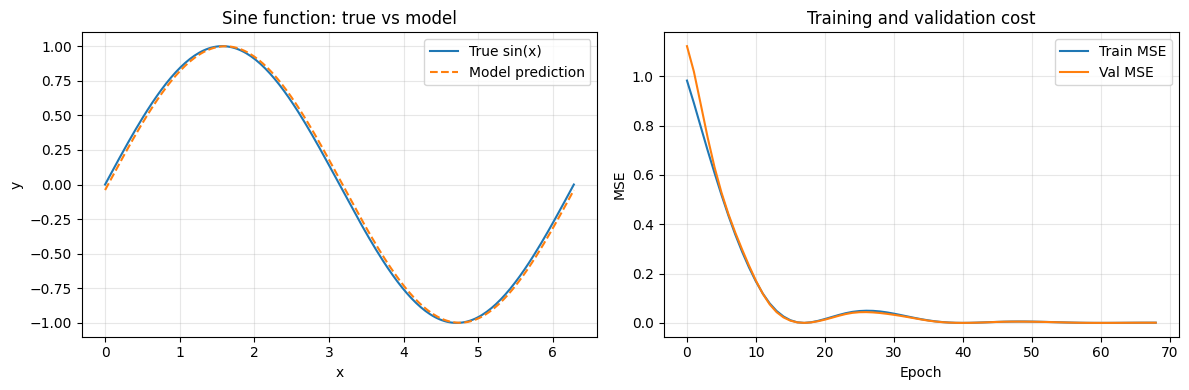

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# true vs predicted sine
axes[0].plot(X_plot, Y_true, label="True sin(x)", color="C0")
axes[0].plot(X_plot, Y_pred, label="Model prediction", color="C1", linestyle="--")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Sine function: true vs model")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# cost history
axes[1].plot(cost_history, label="Train MSE")
axes[1].plot(val_cost_history, label="Val MSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Training and validation cost")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# final metrics
train_mse = cost(weights, bias, X_train, Y_train)
val_mse = cost(weights, bias, X_val, Y_val)

print(f"Final Train MSE: {train_mse:.6f}")
print(f"Final Val MSE:   {val_mse:.6f}")

Final Train MSE: 0.000826
Final Val MSE:   0.000726


## Conclusion

The predicted curve closely follows the true sine curve, and both the training and validation loss reach low values. This indicates that our QML model has learned a good approximation of $\sin(x)$ and generalizes well to unseen points in the interval.

We have therefore completed the goal of implementing a QML model that reproduces the values of the sine function on $[0, 2\pi]$.

Congratulations!

# Credits
This notebook is completed by `Myanmar Youths` for `Womanium Quantum + AI 2024` program.
- <a href="https://www.linkedin.com/in/lawun330/"><u>La Wun Nannda</u></a>
- <a href="https://www.linkedin.com/in/chit-zin-win-46a2a3263/"><u>Chit Zin Win</u></a>